Below contains the code used for the group project

In [6]:
# initial import of libraries
# import more libraries when necessary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
df = pd.read_csv('Concrete_Compressive_Strength.csv')
# set dependent/independent variables
target = "Concrete compressive strength " # there is a space in the original dataset, don't remove it
X = df.drop(columns=[target],inplace=False)
y = df[target]

Exploratory Data Analysis (EDA)

In [3]:
# summary data
print("==== Data Head ====")
print(df.head(), "\n")

print("==== Data Info ====")
print(df.info(), "\n")

print("==== Missing Values ====")
print(df.isnull().sum(), "\n")

print("==== Summary Statistics ====")
print(df.describe(), "\n")

==== Data Head ====
   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age (day)  Concrete compressive strength   
0            1040.0           676.0         28                       79.986111  
1            1055.0           676.0         28                       61.887366  
2             932.0           594.0        270                       40.269535  
3             932.0           594.0        365                       41.052780  
4             978.4           825.5        360                       44.296075   

==== Data Info ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 

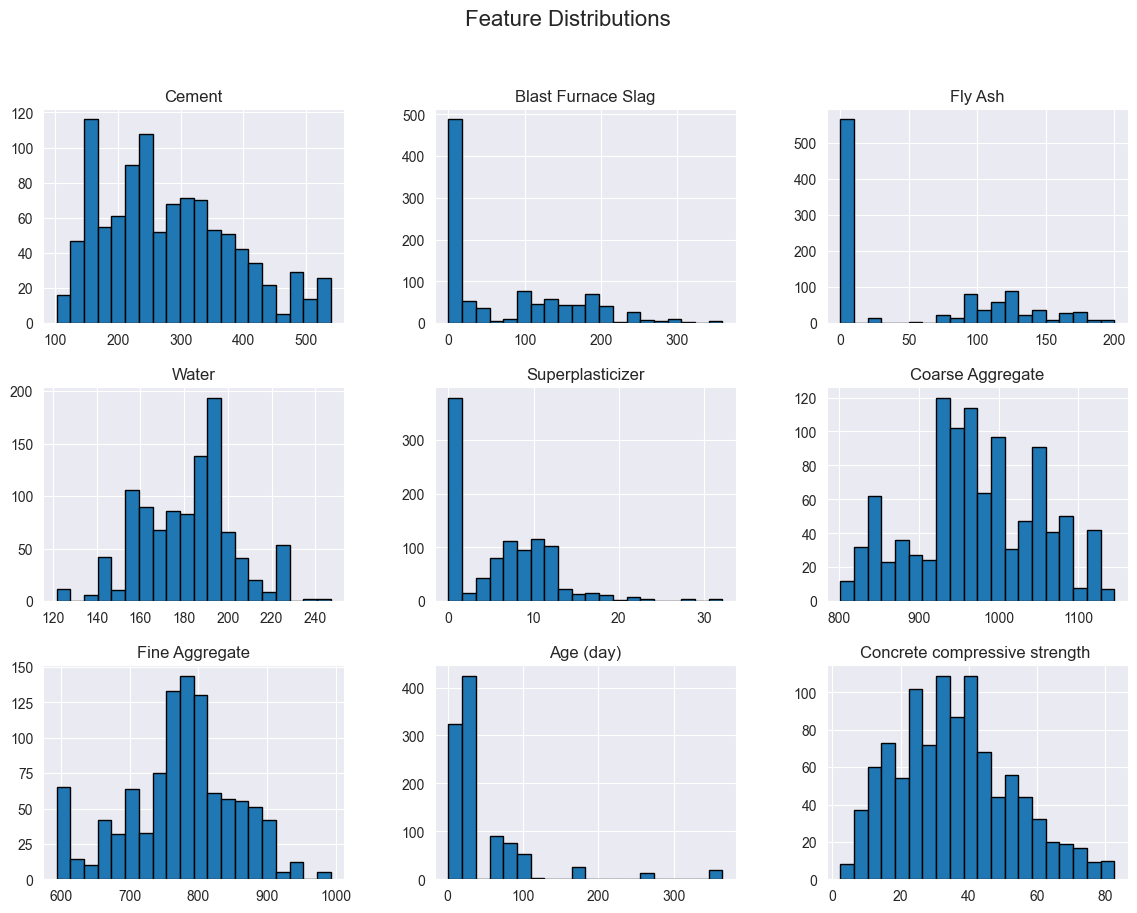

In [4]:
# Histograms
df.hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

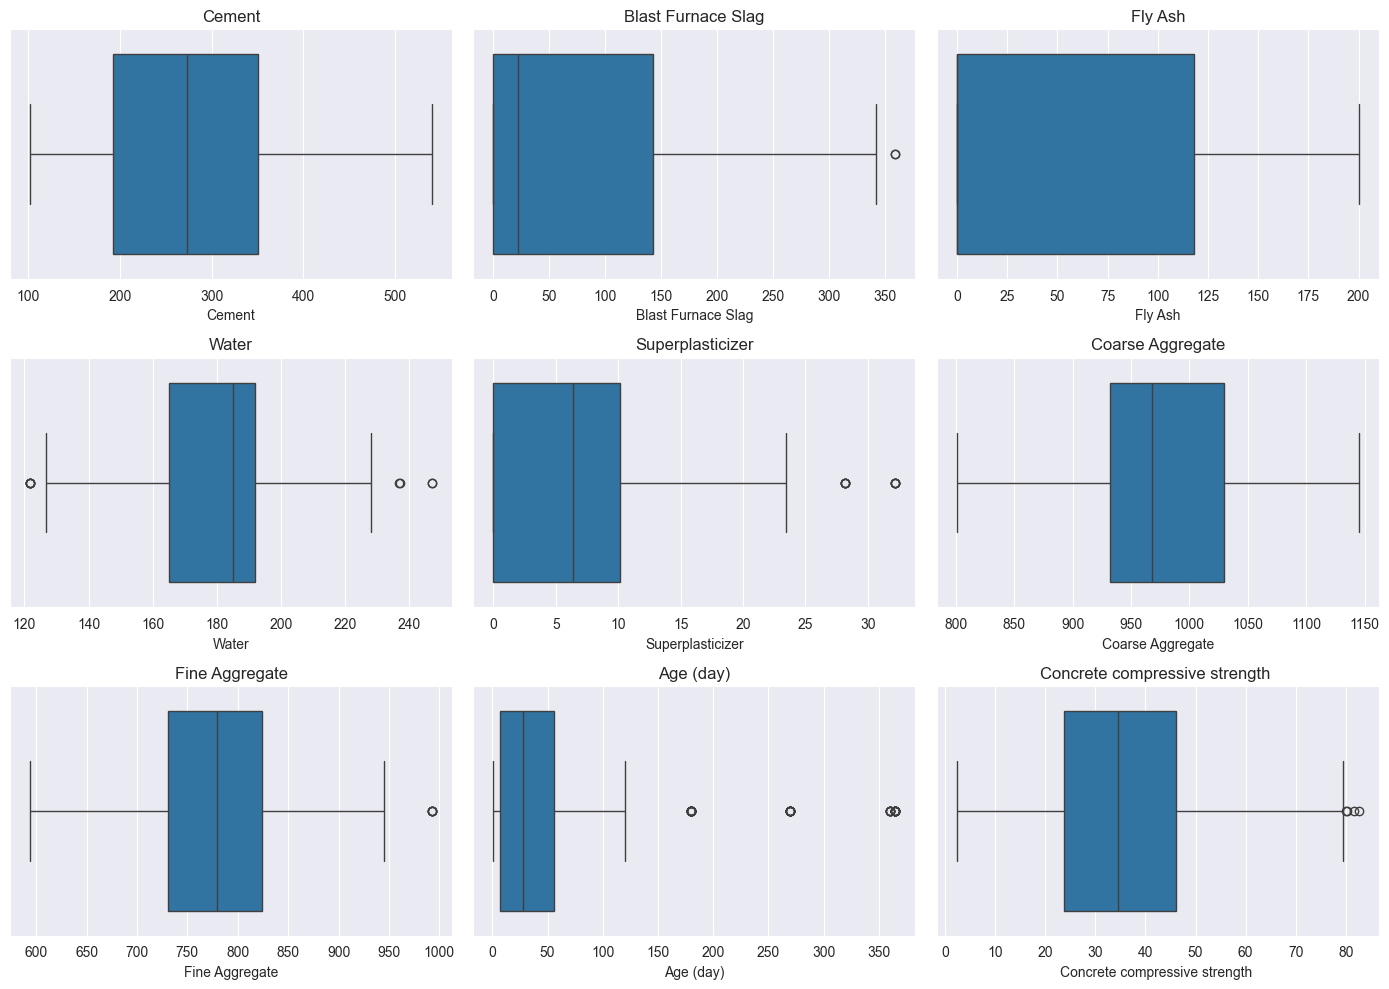

In [7]:
# Box plots （for distributions, outlier etc)
plt.figure(figsize=(14, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

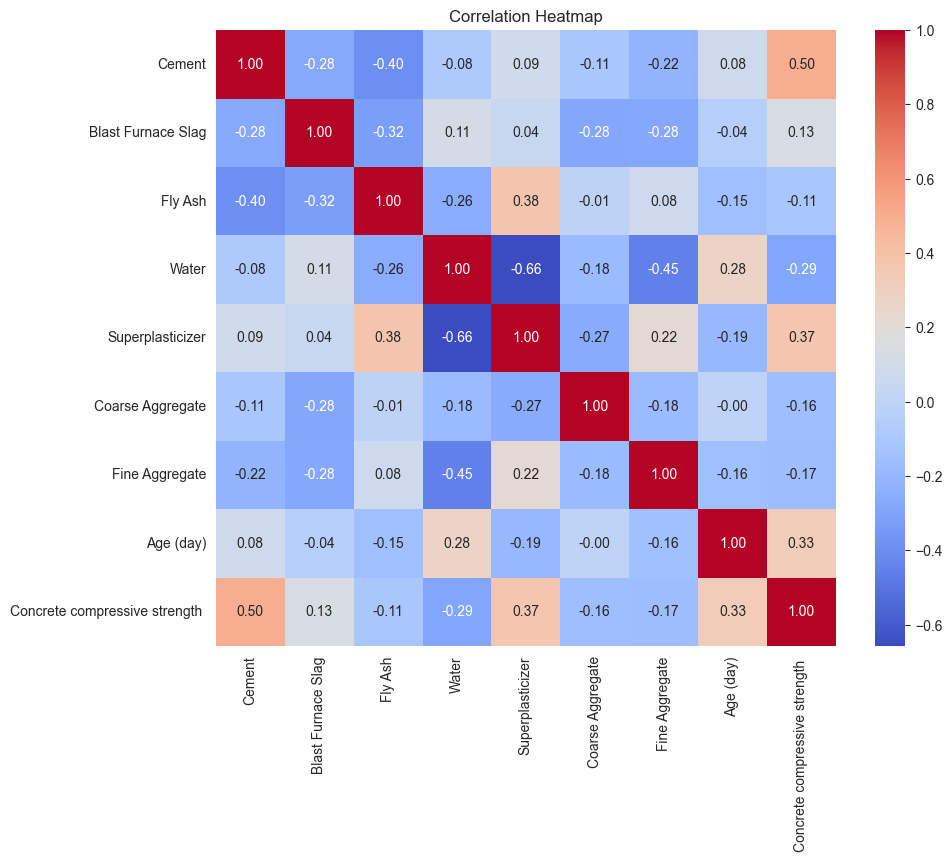

In [8]:
# correlation matrix
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

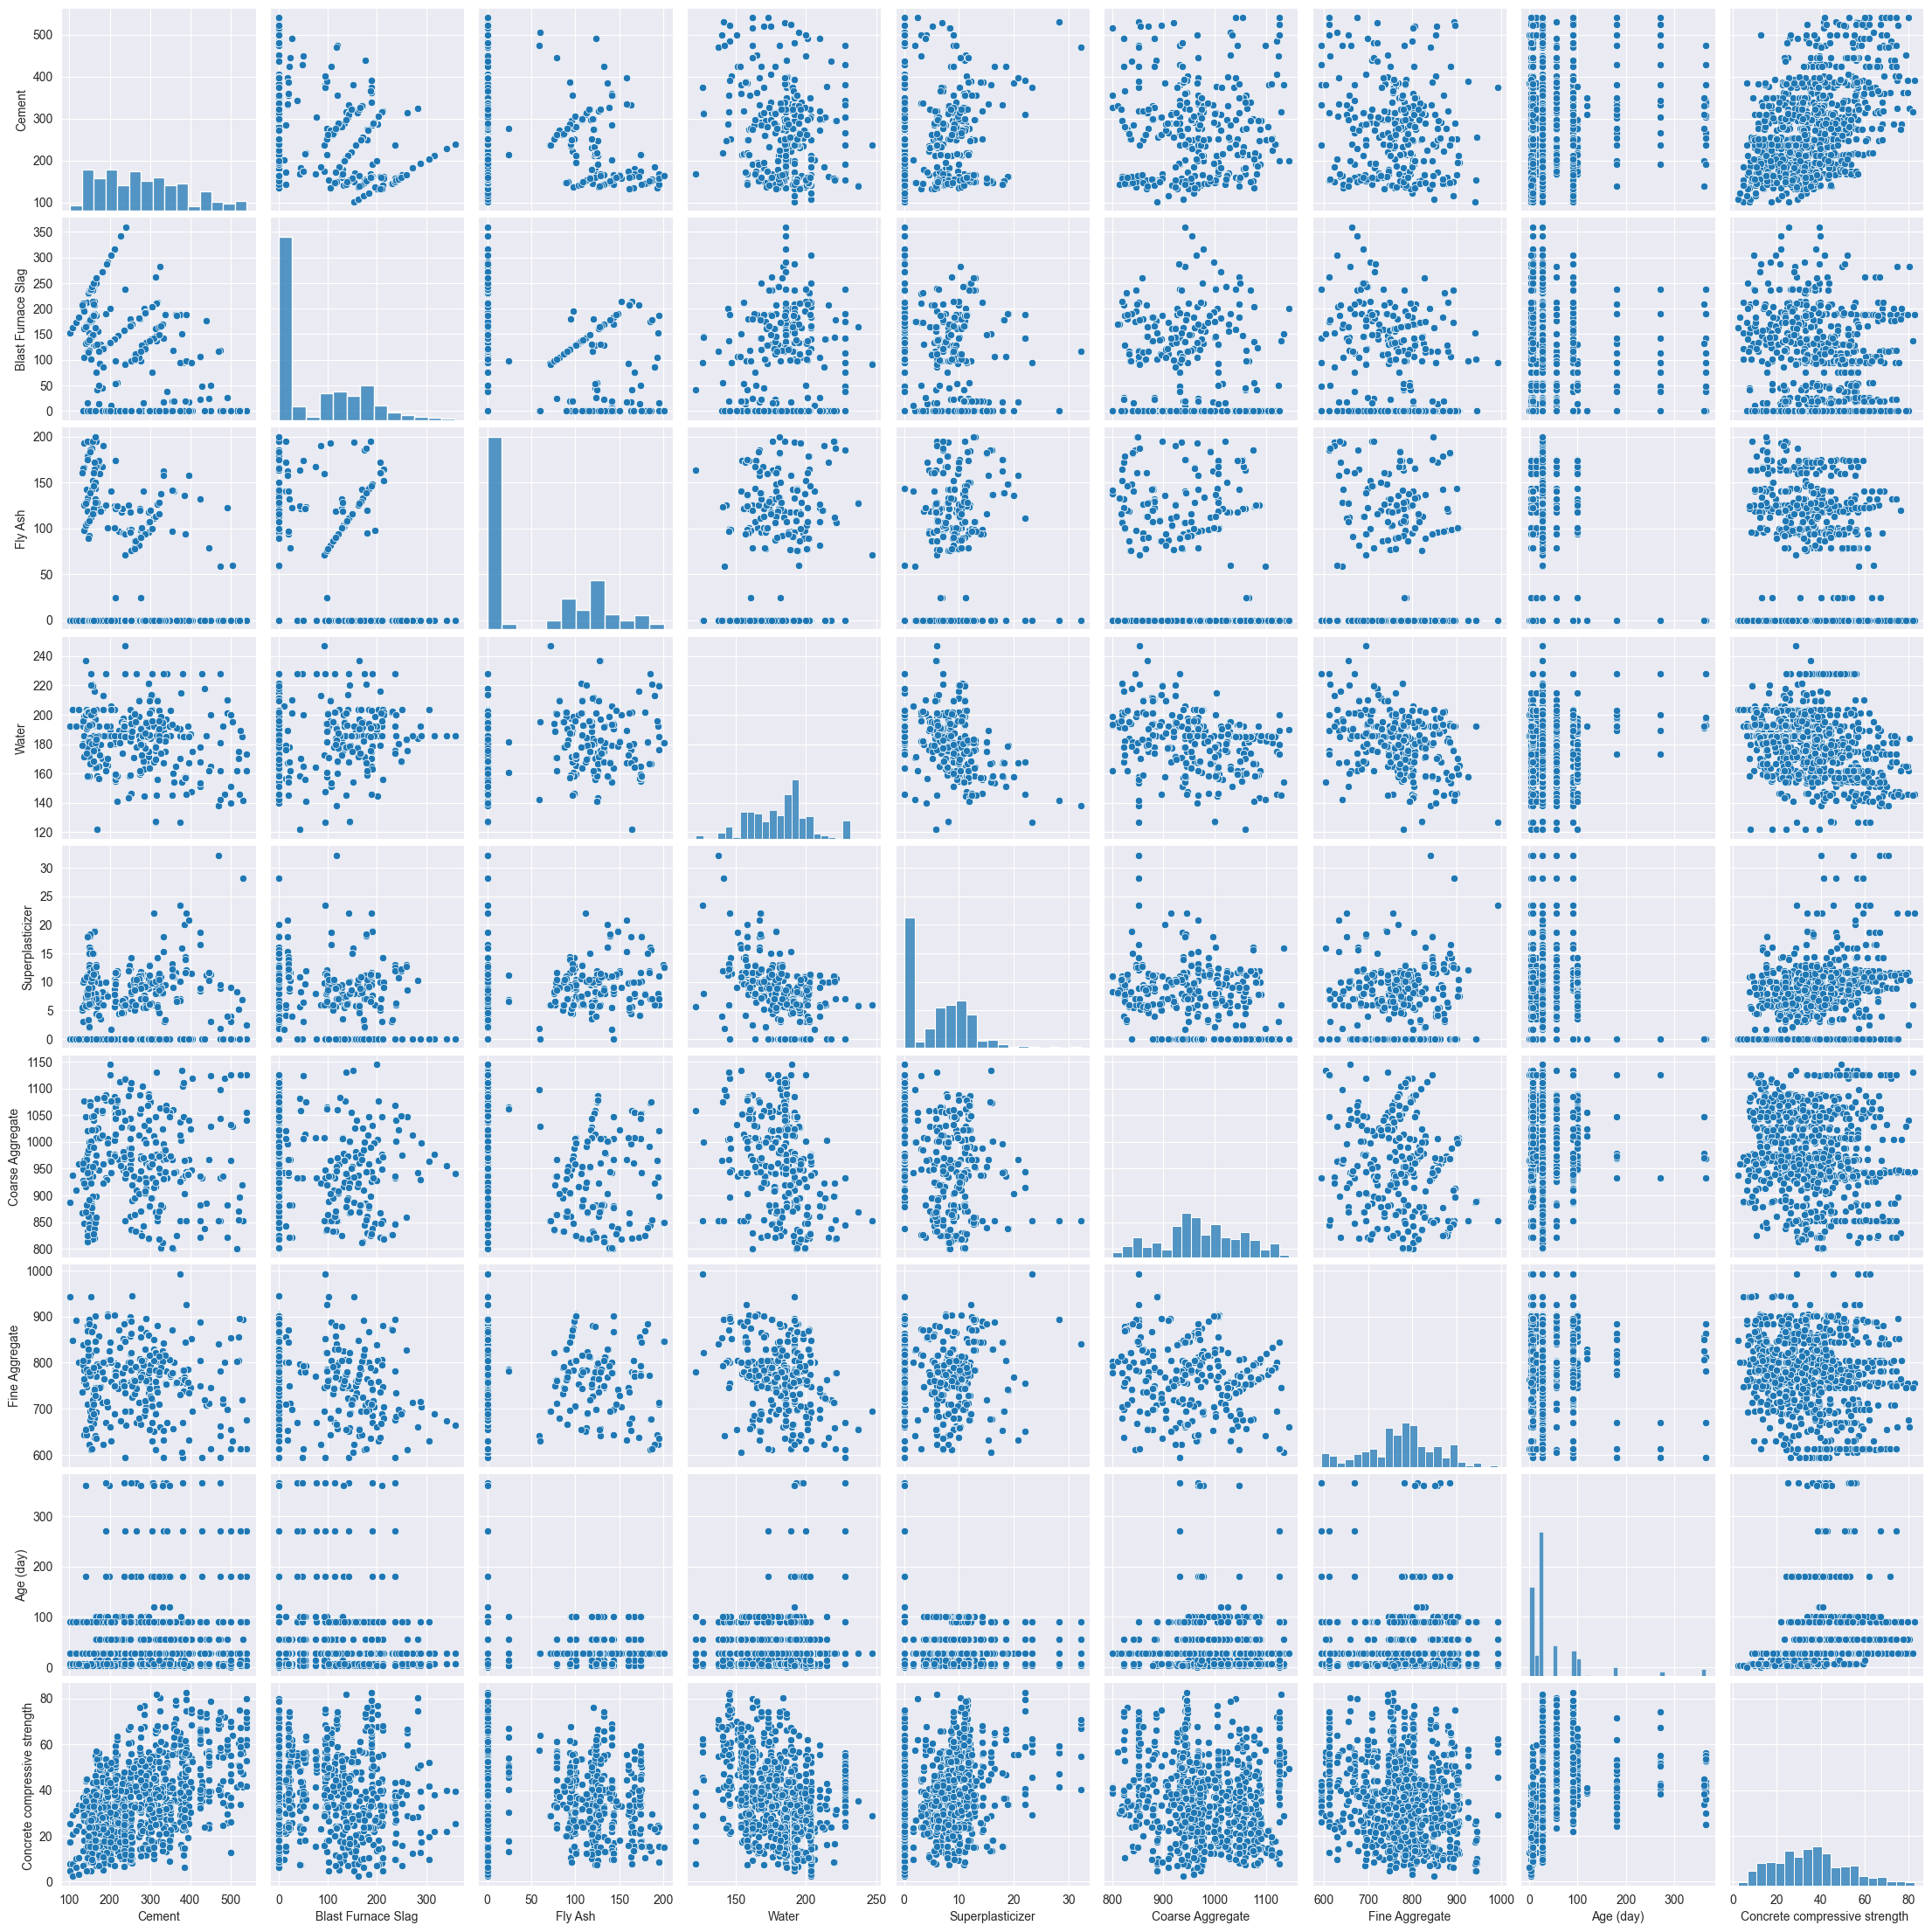

In [9]:
# Paired scatter plots
sns.pairplot(df)
plt.show()

end of EDA, below will be regression related (linear, polynomial, ridge, lasso)

In [10]:
# libraries for regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

In [11]:
# Q-Q plot helper method (used after the model is fit)
# since each model will have its own qq plot, so I make a helper to reuse code
def qq_plot(residuals, title):
    plt.figure(figsize=(7, 5))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(title)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.grid(True)
    plt.show()

In [12]:
# tarin/test split. Current using 80/20, change if necessary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

==== Linear Regression (Scaled) ====
R²: 0.6275416055417096
MSE: 95.97548435260981


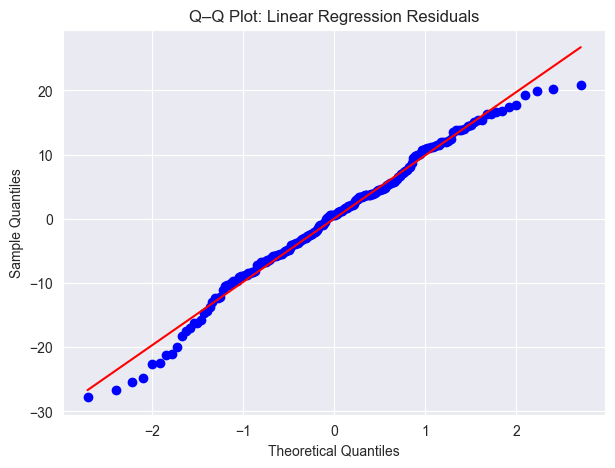

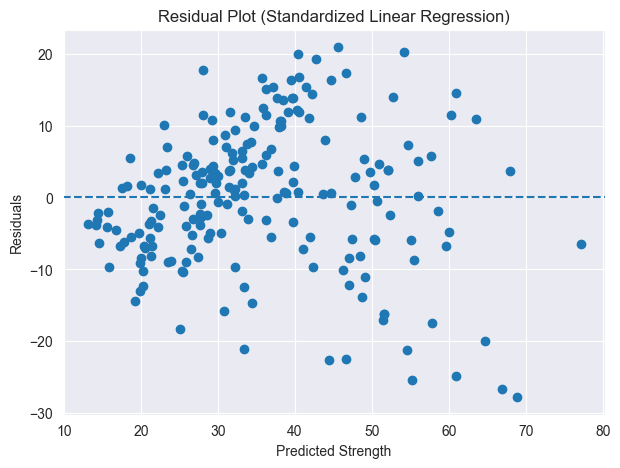

In [21]:
# Linear Regression, scaled
# use MinMaxScaler() if want 0-1
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)
y_pred_linear = linear_pipeline.predict(X_test)

print("==== Linear Regression (Scaled) ====")
print("R²:", r2_score(y_test, y_pred_linear))
print("MSE:", mean_squared_error(y_test, y_pred_linear))


# QQ plot
residuals_linear = y_test - y_pred_linear
qq_plot(residuals_linear, "Q–Q Plot: Linear Regression Residuals")


# residuals for Linear regression.
# if want plot for other regressions, edit or copy this block
residuals = y_test - y_pred_linear

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_linear, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Strength")
plt.ylabel("Residuals")
plt.title("Residual Plot (Standardized Linear Regression)")
plt.grid(True)
plt.show()

==== Polynomial Regression (Degree 2, Scaled) ====
R²: 0.7842685049663733
MSE: 55.589926375746074


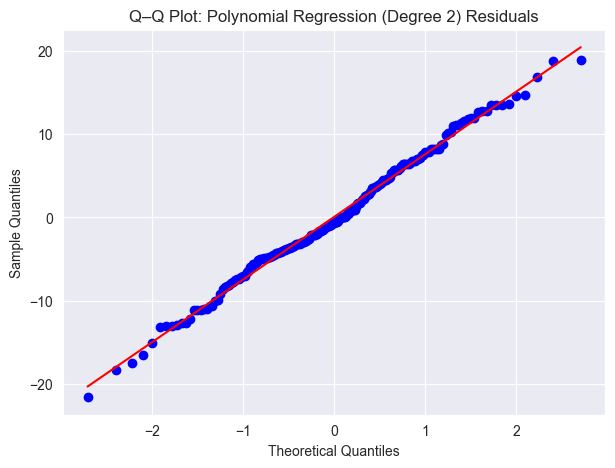

In [18]:
# Polynomial Regression (degree = 2)
# use MinMaxScaler() if want 0-1
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

print("==== Polynomial Regression (Degree 2, Scaled) ====")
print("R²:", r2_score(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))

# QQ plot
residuals_poly = y_test - y_pred_poly
qq_plot(residuals_poly, "Q–Q Plot: Polynomial Regression (Degree 2) Residuals")

==== Ridge Regression (Scaled) ====
R²: 0.6275641808571331
MSE: 95.96966712076747


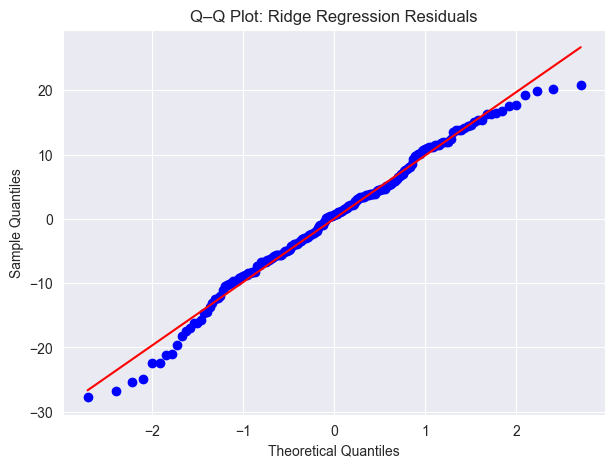

In [19]:
# ridge regression
# use MinMaxScaler() if want 0-1
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

print("==== Ridge Regression (Scaled) ====")
print("R²:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))

# QQ plot
residuals_ridge = y_test - y_pred_ridge
qq_plot(residuals_ridge, "Q–Q Plot: Ridge Regression Residuals")

==== Lasso Regression (Scaled) ====
R²: 0.6275448667106976
MSE: 95.9746440110365


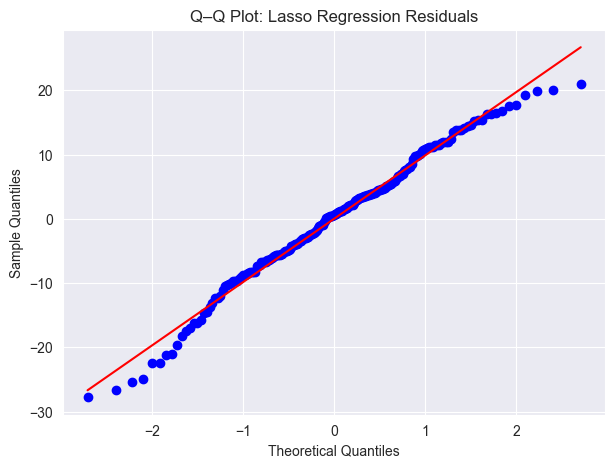

In [20]:
# lasso regression
# use MinMaxScaler() if want 0-1
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.01, max_iter=5000))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

print("==== Lasso Regression (Scaled) ====")
print("R²:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))

# QQ plot
residuals_lasso = y_test - y_pred_lasso
qq_plot(residuals_lasso, "Q–Q Plot: Lasso Regression Residuals")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor